In [14]:
import numpy as np
from scipy.ndimage import laplace, sobel, gaussian_filter, uniform_filter
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import ListedColormap
from config import setup_model_and_geometry
from config import PATH_DATA_DSUB, TMAX

In [56]:
model1, model2, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DSUB)

Operator `initdamp` ran in 0.01 s
Operator `initdamp` ran in 0.01 s


In [37]:
_, sx, sz, _, rec_z = dataset[25]
print(sx, sz)

10.77 -289.98


In [3]:
np.load("gal/gather_10.npy").shape

(13132, 56)

In [4]:
print(model.shape)

(1200, 2005)


In [5]:
815//5 + 1

164

In [6]:
1980//5 + 1

397

In [44]:
velmodel._current_model["vel"].shape

(2005, 805)

In [45]:
np.array(model1.vp.data[500:-500, 500:-500]).T.shape

(2005, 805)

In [ ]:
# velmodel._current_model["vel"] = np.array(model2.vp.data[500:-500, 500:-500]).T
eikonal = EikonalSolver(velmodel, dataset)
_, hodograph2 = eikonal.solve_single(25)
hodograph_samples = (hodograph/model1.critical_dt).astype('int')

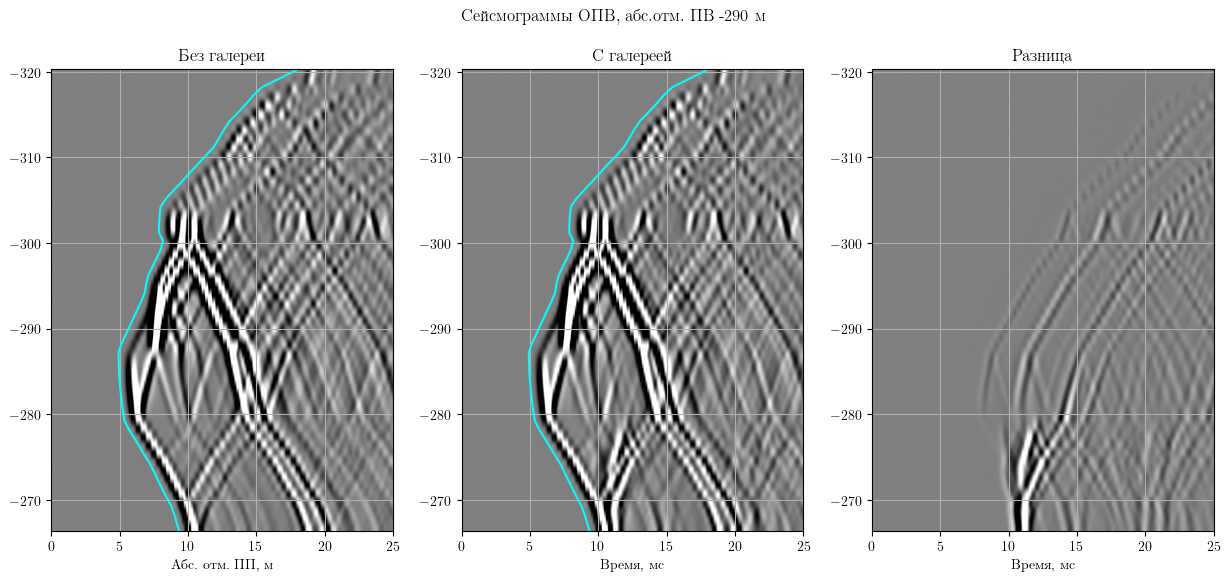

In [85]:
nogal = np.load("nogal/gather_26.npy")
gal = np.load("gal/gather_26.npy")
hod = np.load("hods/hods_26.npy")
qa = np.quantile(gal, 0.985)

fig, axs = plt.subplots(1, 3, figsize=(15, 6))
axs[0].imshow(nogal.T, aspect='auto', vmin=-qa, vmax=qa, extent=[dataset.opposite_elev.min(), dataset.opposite_elev.max(), TMAX, 0][::-1], cmap='gray', interpolation='spline36')
axs[0].plot(hod[:, -2], rec_z, c='cyan')
axs[1].imshow(gal.T, aspect='auto', vmin=-qa, vmax=qa, extent=[dataset.opposite_elev.min(), dataset.opposite_elev.max(), TMAX, 0][::-1], cmap='gray', interpolation='spline36')
axs[1].plot(hod[:, -1], rec_z, c='cyan')
axs[2].imshow(gal.T-nogal.T, aspect='auto', vmin=-qa, vmax=qa, extent=[dataset.opposite_elev.min(), dataset.opposite_elev.max(), TMAX, 0][::-1], cmap='gray', interpolation='spline36')
fig.suptitle(f"Сейсмограммы ОПВ, абс.отм. ПВ -290 м")
titles = ["Без галереи", "С галереей", "Разница"]
for ax, ti in zip(axs, titles):
    # ax.plot(rec_z, hodograph2)

    ax.grid()
    ax.set_xlim([0, 25])
    ax.set_title(ti)
    ax.set_xlabel("Время, мс")

axs[0].set_xlabel("Абс. отм. ПП, м")

plt.show()

In [63]:
print(hod[:, -2] - hod[:, -1])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


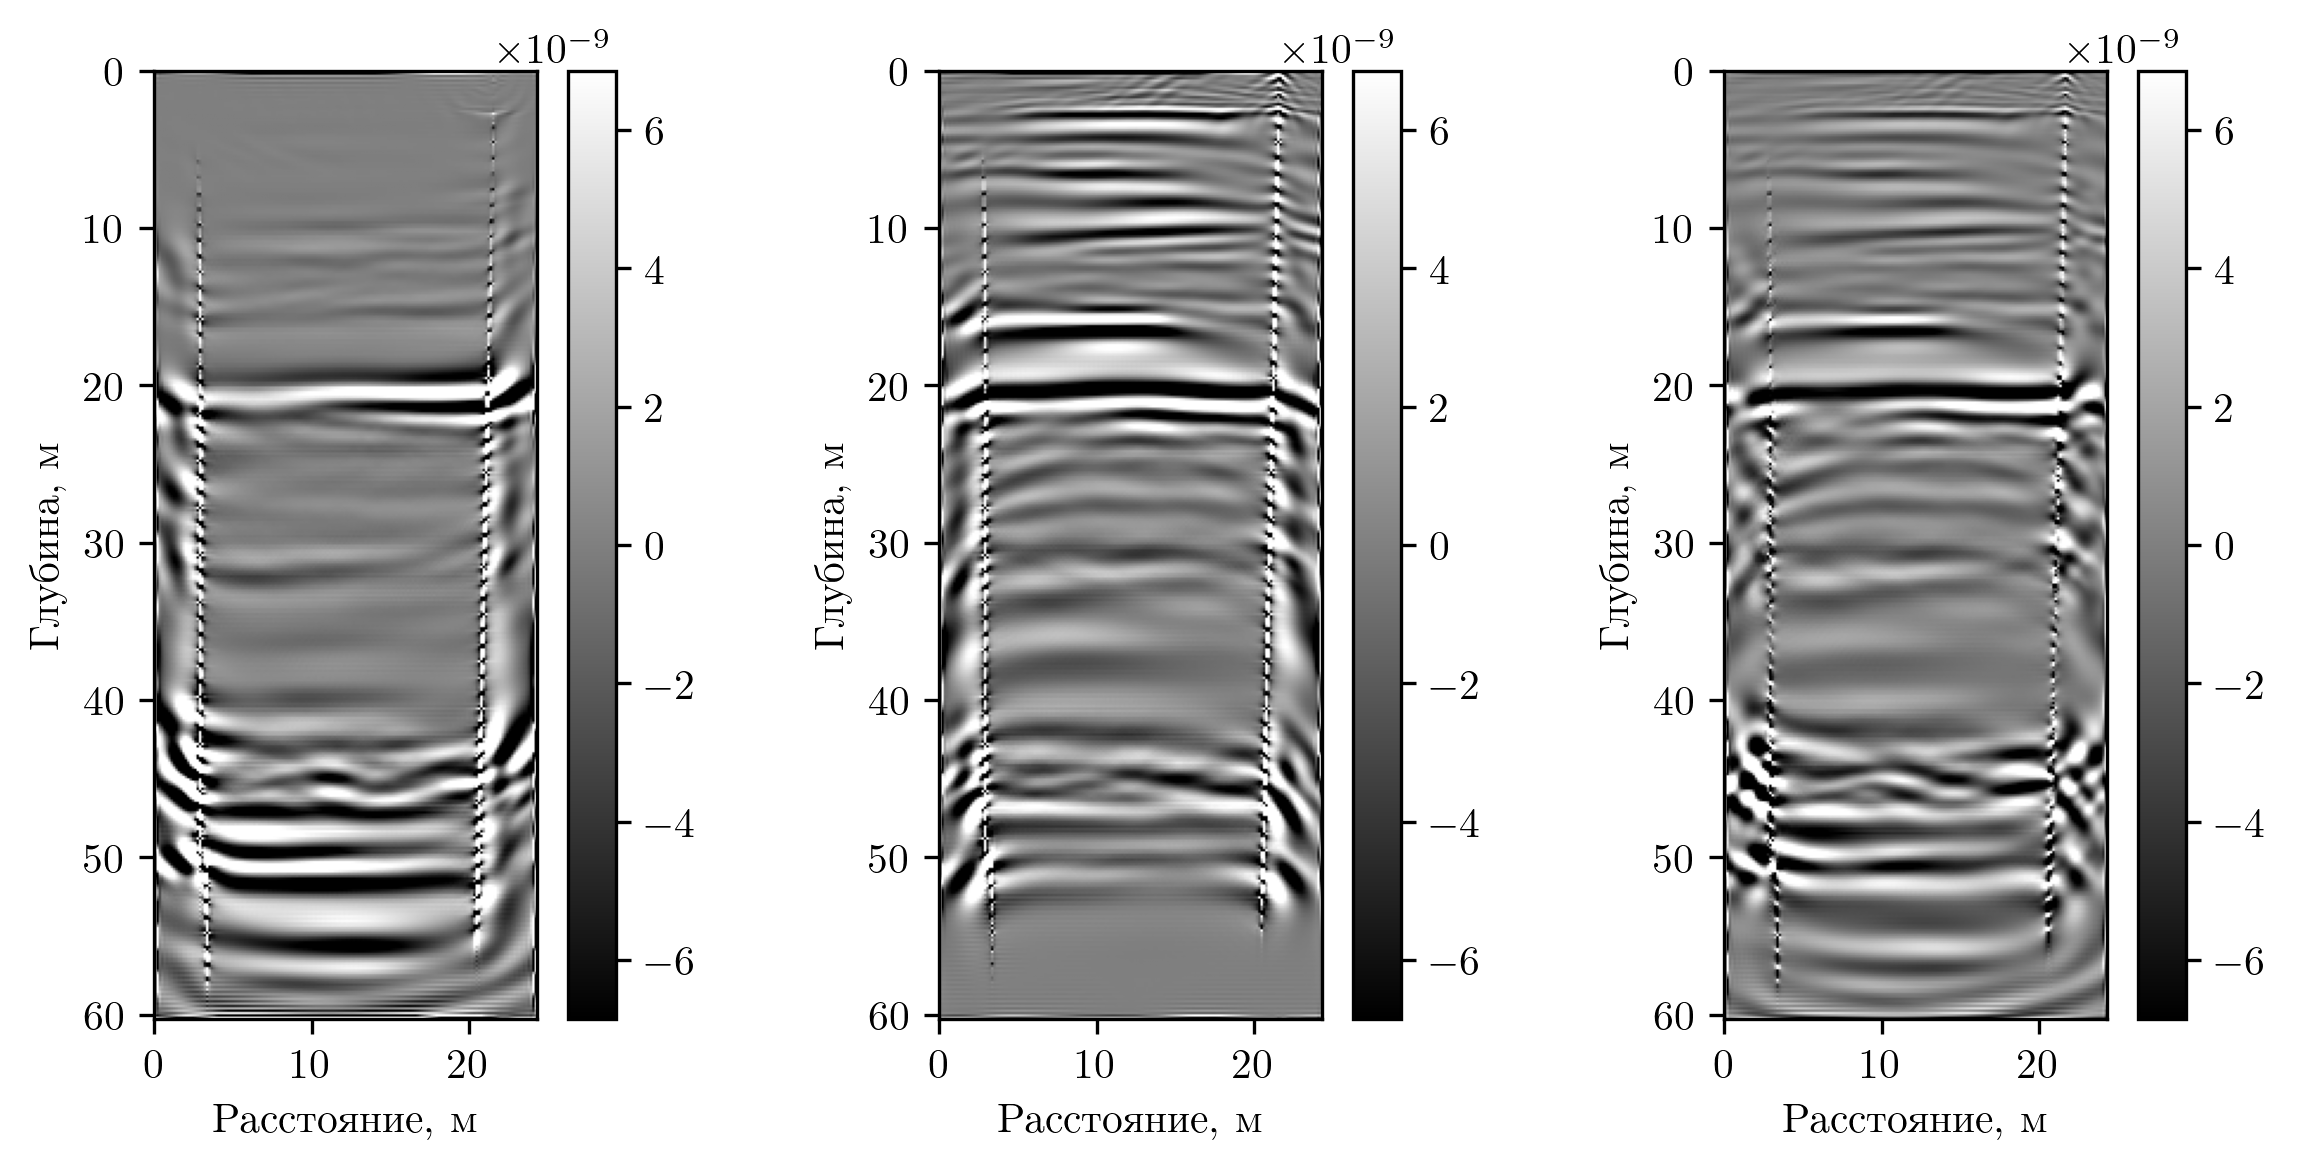

In [12]:
from config import NBL
grad_u0 = np.load("gradients/grad_full_u_0.npy")
grad_d0 = np.load("gradients/grad_full_d_0.npy")

# magnitude[magnitude] = np.nan
fig, axs = plt.subplots(1, 3, figsize=(8, 4), dpi=300)
# glmax = max([np.max(np.abs(grad_d)), np.max(np.abs(grad_u))])
glmax = max([np.quantile(grad_d0, 0.9), np.quantile(grad_u0, 0.9)])
# imag0 = grad_u0-grad_d0
imag0 = np.load("images/image_iter_2.npy")[::5, ::5]
for gr, ax in zip([grad_d0, grad_u0, imag0], axs):
    # h=ax.imshow(np.diff(gr.T, axis=0, n=2), cmap='gray', vmin=-glmax/5, vmax=glmax/5)
    # h=ax.imshow(-np.diff(gaussian_filter(gr.T, sigma=0), axis=0, n=1), cmap='gray', vmin=-glmax/2.5*3e3, vmax=glmax/2.5*3e3, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])

    # h=ax.imshow(laplace(gr.T), cmap='gray', vmin=-glmax/5, vmax=glmax/5, extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    # h=ax.imshow(laplace(gaussian_filter(gr.T, sigma=0.9)), vmin=-glmax/3, vmax=glmax/3, cmap='gray', extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    # h=ax.imshow(np.diff(uniform_filter(gr.T, size=[5, 5]), axis=0, n=2), vmin=-glmax/10, vmax=glmax/10, cmap='gray', extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])

    h=ax.imshow(laplace(gr.T),
                vmin=-glmax/5, vmax=glmax/5,
                cmap='gray', extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    #hh=ax.imshow(model.vp.data[NBL:-NBL, NBL:-NBL].T, cmap='jet', vmin=0.5, vmax=5.5, alpha=0.3, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

    fig.colorbar(h)



plt.tight_layout()
plt.show()

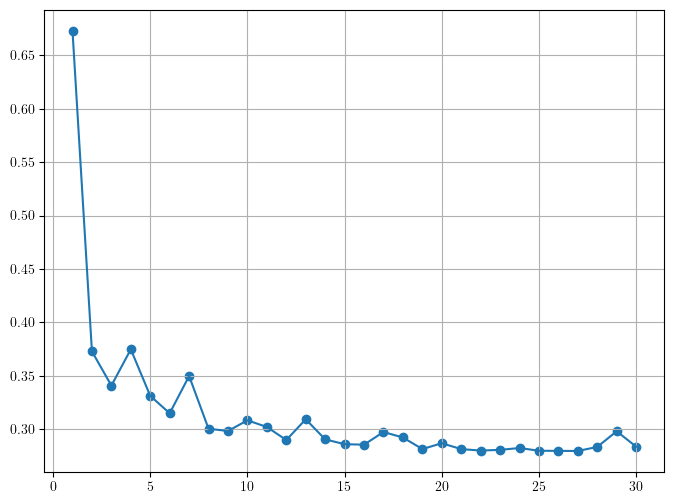

In [6]:
errs = [0.67292, 0.37280, 0.34077, 0.37472, 0.33117, 0.31484, 0.34977, 0.30034, 0.29826, 0.30825, 0.30201, 0.28980, 0.30924, 0.29042, 0.28591, 0.28543, 0.29731, 0.29218, 0.28135, 0.28677, 0.28129, 0.27994, 0.28059, 0.28232, 0.27976, 0.27964, 0.27954, 0.28336, 0.29800, 0.28358]
plt.plot(np.arange(1, len(errs)+1), errs)
plt.scatter(np.arange(1, len(errs)+1), errs)
plt.grid()
plt.show()

In [ ]:
# Your data
errs = [0.67292, 0.37280, 0.34077, 0.37472, 0.33117, 0.31484, 0.34977,
        0.30034, 0.29826, 0.30825, 0.30201, 0.28980, 0.30924, 0.29042,
        0.28591, 0.28543, 0.29731, 0.29218, 0.28135, 0.28677, 0.28129,
        0.27994, 0.28059, 0.28232, 0.27976, 0.27964, 0.27954, 0.28336,
        0.29800, 0.28358]

fig = plt.figure(figsize=(12, 6), dpi=150)
gs = fig.add_gridspec(3, 2, width_ratios=[1.5, 1], height_ratios=[1, 2.5, 1])  # First row will be 1/4 height

ax1 = fig.add_subplot(gs[1, 0])  # Error plot takes all rows in first column
ax2 = fig.add_subplot(gs[:, 1])  # Image plot takes bottom right

ax1.plot(np.arange(1, len(errs)+1), errs)
ax1.scatter(np.arange(1, len(errs)+1), errs)
ax1.set_xlim([1, 30])
ax1.set_ylim([0.2, 0.7])

ax1.grid()
ax1.set_xlabel('№ Итерации')
ax1.set_ylabel(r'$\| d-d_{obs} \Vert$')
red_dot, = ax1.plot([1], [errs[0]], 'ro')  # Initial red dot

# Set up the image subplot
ax2.set_xlabel("Расстояние, м")
ax2.set_ylabel("Глубина, м")
# glmax = 1  # Adjust this based on your actual image data
img = ax2.imshow(np.zeros((10, 10)), cmap='gray', vmin=-glmax/1, vmax=glmax/1, extent=[0, grad_d1.shape[0]*0.25, grad_d1.shape[1]*0.25, 0])
plt.colorbar(img, ax=ax2)

# Pre-load all images (assuming they're named image_iter_0.npy to image_iter_29.npy)
images = []
for i in range(len(errs)):
    try:
        # Load and downsample the image
        img_data = np.load(f"images/image_iter_{i}.npy")[::10, ::10]
        images.append(img_data)
    except:
        # If image doesn't exist, use zeros
        images.append(np.zeros_like(images[-1]) if len(images) > 0 else np.zeros((10, 10)))

def update(frame):
    # Update red dot position
    red_dot.set_data([frame+1], [errs[frame]])
    
    # Update image
    current_img = images[frame]
    img.set_array(np.diff(current_img.T, axis=0, n=1))
    
    # Adjust color scale if needed (optional)
    # new_glmax = np.max(np.abs(np.diff(current_img.T, axis=0, n=1)))
    # img.set_clim(vmin=-new_glmax/1, vmax=new_glmax/1)
    
    return red_dot, img

# Create animation
ani = FuncAnimation(fig, update, frames=len(errs), interval=500, blit=False)

plt.close(ani._fig)
HTML(ani.to_html5_video())

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(8, 6))
qa1 = np.quantile(snapsObj, 0.999)
qa2 = np.quantile(sd, 0.999)

matrice1 = ax[0].imshow(snapsObj[0, :, :].T, vmin=-qa1, vmax=qa1, cmap="seismic")
matrice2 = ax[1].imshow(sd[0, :, :].T, vmin=-qa2, vmax=qa2, cmap="seismic")
fig.colorbar(matrice1)
fig.colorbar(matrice2)

for axi in ax:
    axi.set_xlabel('X')
    axi.set_ylabel('z')

plt.tight_layout()
def update(i):
    matrice1.set_array(snapsObj[i, :, :].T)
    matrice2.set_array(sd[i, :, :].T)
    
    return matrice1, matrice2, 

# Animation
ani = animation.FuncAnimation(fig, update, frames=nsnaps, interval=50, blit=True)

plt.close(ani._fig)
HTML(ani.to_html5_video())

In [68]:
from image_update import upsample_image

def get_model_shape():
    return 1630, 2640

grad_upsampled = upsample_image(imag0, *get_model_shape())
print(grad_upsampled.shape)
np.save("../lsrtm/images/image_iter_0.npy", -grad_upsampled)

(1630, 2640)


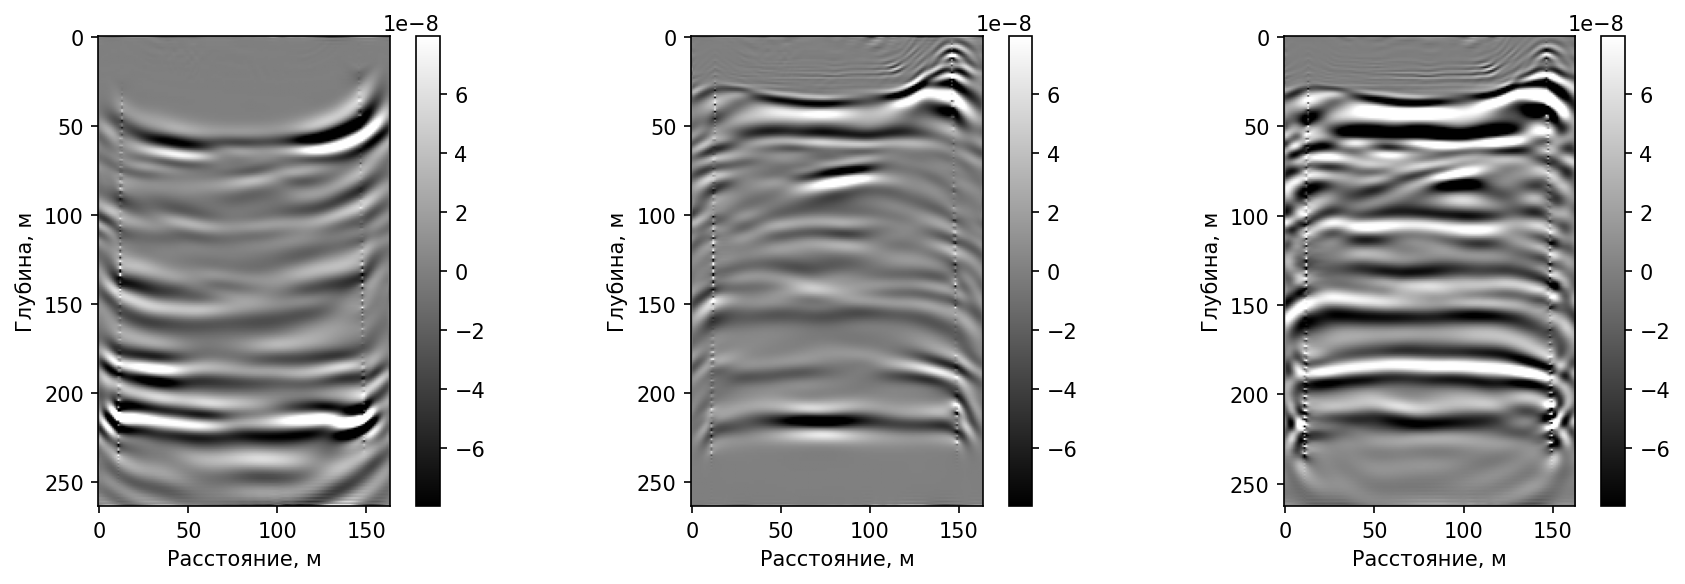

In [54]:
grad_u2 = np.load("gradients/grad_full_u_2.npy")
grad_d2 = np.load("gradients/grad_full_d_2.npy")
# magnitude[magnitude] = np.nan
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=150)
# glmax = max([np.max(np.abs(grad_d)), np.max(np.abs(grad_u))])
# glmax = max([np.quantile(grad_d1, 0.98), np.quantile(grad_u1, 0.98)])
grad2 = grad_d2-grad_u2

# imag2 = imag1 - grad2*0.2
imag2 = np.load("images/image_iter_5.npy")[::10, ::10]
for gr, ax in zip([grad_d2, grad_u2, imag2], axs):
    # h=ax.imshow(np.diff(gr.T, axis=0, n=2), cmap='gray', vmin=-glmax/5, vmax=glmax/5)
    h=ax.imshow(np.diff(gr.T, axis=0, n=1), cmap='gray', vmin=-glmax/3, vmax=glmax/3)
    # h=ax.imshow(laplace(gr.T), cmap='gray', vmin=-glmax/5, vmax=glmax/5, extent=[0, grad_d1.shape[0]*0.25, grad_d1.shape[1]*0.25, 0])
    # h=ax.imshow(gr.T, cmap='gray', vmin=-glmax/1, vmax=glmax/1, extent=[0, grad_d1.shape[0]*0.25, grad_d1.shape[1]*0.25, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

    fig.colorbar(h)



plt.tight_layout()
plt.show()

In [ ]:
from image_update import upsample_image

def get_model_shape():
    return 1630, 2640

grad_upsampled = upsample_image(imag2, *get_model_shape())
print(grad_upsampled.shape)
# np.save("../lsrtm/images/image_iter_2.npy", grad_upsampled)

(1630, 2640)


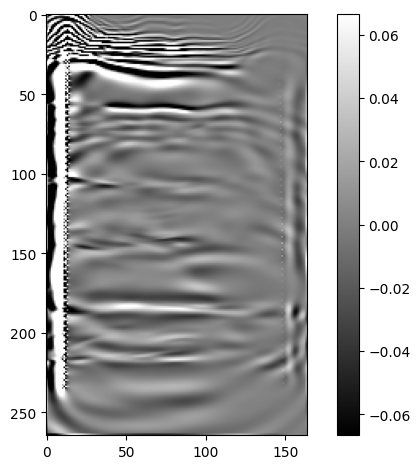

In [91]:
grad1 = np.load("gradients/grad_full_0.npy")
buff = grad1.T*1000
qa = np.quantile(buff, 0.99)
# h=plt.imshow(buff, cmap='gray', vmin=-qa, vmax=qa)
h=plt.imshow(laplace(buff), cmap='gray', vmin=-qa/1e1, vmax=qa/1e1)

plt.colorbar(h)
plt.tight_layout()
plt.show()

In [ ]:

from config import *
import torch
def get_model_shape():
    return 1630, 2640

def get_num_shots():
    return 59
def load_wavefield_snaps_batch(shot_ids, wavefield_type='forward'):
    dir_path = OUTPUT_DIRS['forward_snaps'] if wavefield_type == 'forward' else OUTPUT_DIRS['adjoint_snaps']
    nx, nz = get_model_shape()
    sub_nx = nx // SUBSAMPLING + 1
    sub_nz = nz // SUBSAMPLING + 1
    
    batch = torch.empty((len(shot_ids), NSNAPS, sub_nx, sub_nz),
                    dtype=torch.float32,
                    pin_memory=True)
    
    for i, shot_id in enumerate(shot_ids):
        path = f"{dir_path}/{shot_id+1}.npy"
        batch[i] = torch.from_numpy(np.load(path))  # Copy forces read into memory
    
    return batch

In [7]:
# shot_ids = range(0, get_num_shots(), 10)

from grad_computation import load_wavefield_snaps_batch

shot_ids = range(0, 10)

u0_batch = load_wavefield_snaps_batch(shot_ids, 'forward')
v_batch = load_wavefield_snaps_batch(shot_ids, 'adjoint')

print(u0_batch.numpy().shape)

(10, 500, 164, 397)


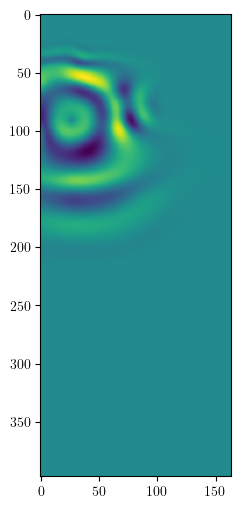

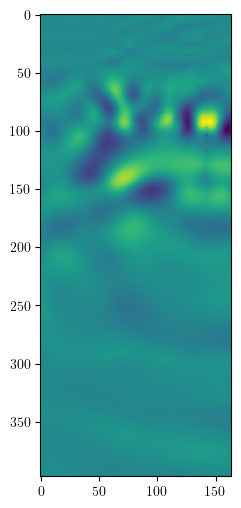

In [14]:
N = 5
K = 100
plt.imshow(u0_batch.numpy()[N][K].T)
plt.show()
plt.imshow(v_batch.numpy()[N][K].T)
plt.show()

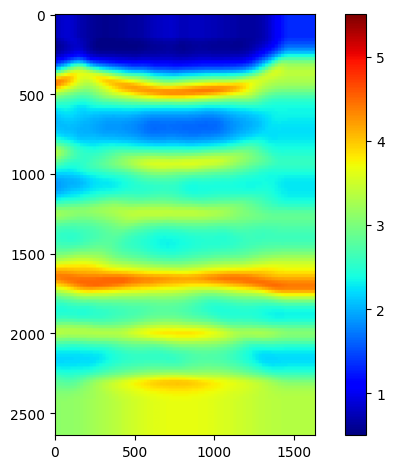

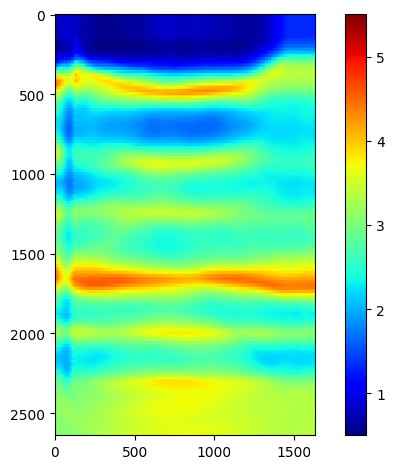

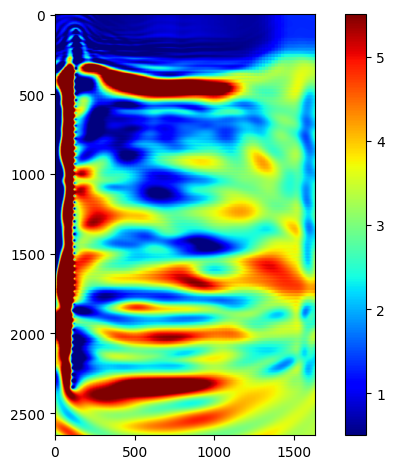

In [66]:
for i in range(0, 3):
    path = f"images/image_iter_{i}.npy"
    grad1 = np.load(path)
    buff = grad1.T
    # h = plt.imshow(buff, cmap='jet', vmin=qa1, vmax=qa2)
    h = plt.imshow(buff, cmap='jet', vmin=0.5, vmax=5.5)
    plt.gcf().colorbar(h)
    plt.tight_layout()
    plt.savefig(f"pngs/_{i}.png")
    plt.show()

In [8]:
from wavefield_computation import setup_model_and_geometry
import numpy as np
model, dataset = setup_model_and_geometry(29)

(1630, 2640)


Operator `initdamp` ran in 0.01 s


In [5]:
from config import *
d_syn = np.load(f"{OUTPUT_DIRS['forward_snaps']}/recon_gather_{20}.npy")
print(d_syn.shape)

(12984, 57)


In [6]:
dataset._dt_r = model.critical_dt
dataset._t_max_r = 40.0
dataset.resample_on()
d_obs = dataset[20][0]
print(d_obs.shape)

(57, 12984)


In [7]:
print(np.quantile(d_obs, 0.99))
print(np.quantile(d_syn, 0.99))
scale_factor = np.sqrt(np.sum(d_obs.ravel()**2))/np.sqrt(np.sum(d_syn.ravel()**2))
print(scale_factor)

3.218513935875701
0.006853265
446.16755457217005


In [9]:

d_obs /= scale_factor

In [11]:
print(np.linalg.norm(d_syn.ravel()))
print(np.linalg.norm(d_obs.ravel()))

2.1409204
2.140921592712403


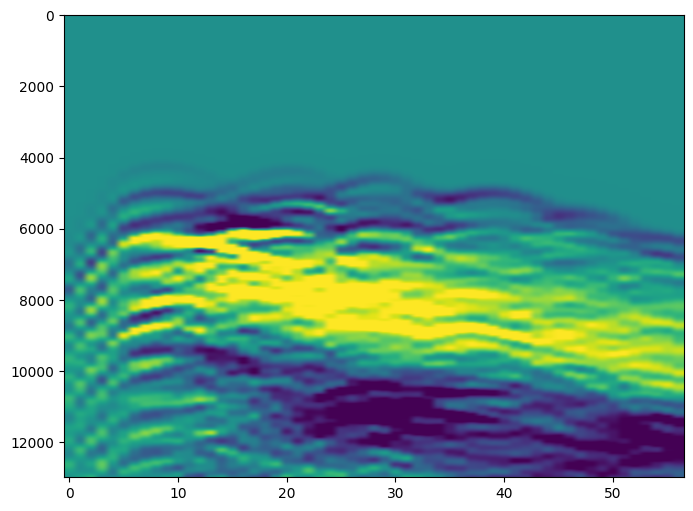

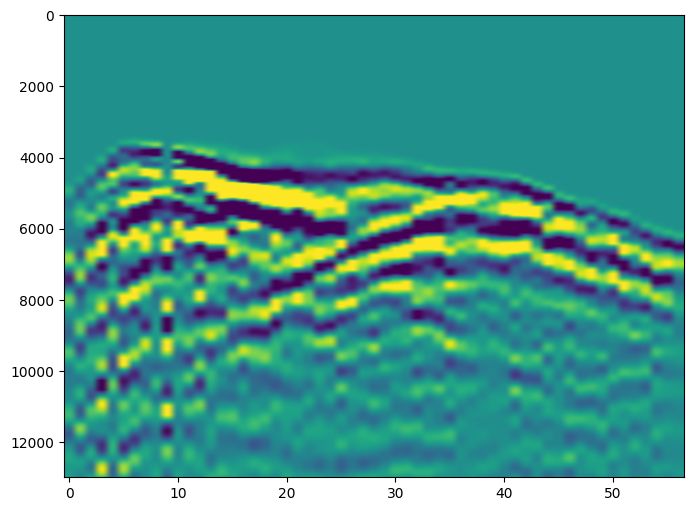

In [10]:
from matplotlib import pyplot as plt
qa = 0.005
plt.imshow(d_syn, aspect='auto', vmin=-qa, vmax=qa)
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.show()